<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-03/trabalho-03/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Equipe**: 01<br>
> **Estudantes**: Cristina Siewert Jansen, Marlon Sbardelatti e Sofia Sousa Lindner

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# PARTE 3: Regressão Logística

**1. Utilize a base de dados construída no Trabalho 3 ‘risco_credito.pkl’, que possui 14 registros, para testar o algoritmo de Regressão Logística.**

In [6]:
import pickle
with open('risco_credito.pkl', 'rb') as f:
  X_credit_risk, y_credit_risk = pickle.load(f)

**2. Faça o Encoder dos dados e, para facilitar, como fizemos na aula teórica, apague os registros que possuem a classe ‘moderado’. No total teremos 11 registros.**

In [7]:
from sklearn.preprocessing import LabelEncoder

# Não entendi por que fazer o Encoder dos dados

In [8]:
# Filtra 'moderado' através da indexação booleana dos registros com classe
filter_moderate_class = y_credit_risk != 2

X_credit_risk = X_credit_risk[filter_moderate_class]
y_credit_risk = y_credit_risk[filter_moderate_class]

# Verifica tamanho
print(X_credit_risk.shape)
print(y_credit_risk.shape)

# Verifica que há somente classes 0 e 1
print(y_credit_risk)

(11, 4)
(11,)
[0 0 0 1 1 0 1 1 0 1 0]


**3. Treine o algoritmo de regressão logística e utilize o parâmetro ‘random_state =1’ para ter sempre o mesmo resultado.**

In [9]:
from sklearn.linear_model import LogisticRegression

# Treinamento do modelo
logistic_regression_risk = LogisticRegression(random_state=1)
logistic_regression_risk.fit(X_credit_risk, y_credit_risk)

LogisticRegression(random_state=1)

**4. Utilize o comando ‘.intercept_’ para ter o resultado do B0.
O resultado deve ser =-0.80828993.**

In [10]:
logistic_regression_risk.intercept_

array([-0.80855152])

**5. Utilize o comando ‘.coef_’ para ter o resultado dos demais parâmetros que deve ser:
`array([[-0.76704533,  0.23906678, -0.47976059,  1.12186218]])`**

In [11]:
logistic_regression_risk.coef_

array([[-0.76706797,  0.23921064, -0.47989768,  1.12196145]])

**6. Agora utilize o comando ‘predict’ para fazer o teste do seu algoritmo com:**

a) história boa, dívida alta, garantias nenhuma, renda > 35 (o resultado desse teste deve ser ‘baixo’)<br>
b) história ruim, dívida alta, garantias adequada, renda < 15 (o resultado desse teste deve ser ‘alto’)

In [12]:
test_data = np.array([
    [0, 0, 1, 2], # história boa, dívida alta, garantias nenhuma, renda > 35
    [2, 0, 0, 0]  # história ruim, dívida alta, garantias adequada, renda < 15
])

predictions_credit_risk = logistic_regression_risk.predict(test_data)

TARGET_NAMES = ['alto', 'baixo']

print([TARGET_NAMES[p] for p in predictions_credit_risk])

['baixo', 'alto']


##Algoritmo de Regressão Logística para uma base de dados maior (Credit Data)

**7. Agora aplique a Regressão Logística na base de dados ‘credit.pkl’. De quanto foi a taxa de acerto?**

In [13]:
# Abrir o arquivo
with open('credit.pkl', 'rb') as f:
  X_credit_train, y_credit_train, X_credit_test, y_credit_test = pickle.load(f)

In [14]:
logistic_regression_credit = LogisticRegression(random_state=1)

logistic_regression_credit.fit(X_credit_train, y_credit_train)

credit_predictions = logistic_regression_credit.predict(X_credit_test)

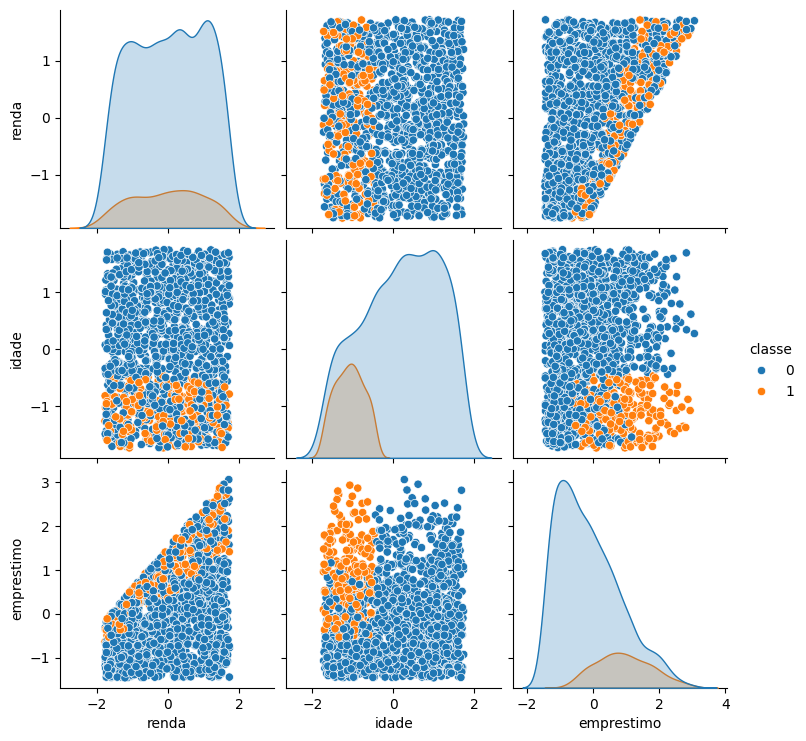

In [15]:
ATTRIBUTE_NAMES = ['renda', 'idade', 'emprestimo']
CLASS_NAMES = ['paga', 'nao paga']

# Transformar em DataFrame
df_credit = pd.DataFrame(X_credit_train, columns=ATTRIBUTE_NAMES)
df_credit['classe'] = y_credit_train

# Gerar visualização gráfica 2d da combinação de todas as classes
sns.pairplot(df_credit, hue='classe')

plt.show()

In [16]:
# Gerar visualização gráfica 3d
fig = px.scatter_3d(
    df_credit,
    x=ATTRIBUTE_NAMES[0],
    y=ATTRIBUTE_NAMES[1],
    z=ATTRIBUTE_NAMES[2],
    color='classe'
)

fig.show()

In [17]:
from sklearn.metrics import accuracy_score

# Função utilitária para exibir erros em relação ao total e calcular acurácia
def calculate_accuracy(expected: np.ndarray, predictions: np.ndarray):
  count_diff = 0
  total = len(predictions)
  for i in range(total):
    if predictions[i] != expected[i]:
      count_diff += 1

  print(f'Previsões corretas:  {total - count_diff}/{total}')
  print(f'Previsões incorretas: {count_diff}/{total}')
  print(f'Acurácia: {accuracy_score(expected, predictions)}')

In [18]:
calculate_accuracy(y_credit_test, credit_predictions)

Previsões corretas:  473/500
Previsões incorretas: 27/500
Acurácia: 0.946


A acurácia da regressão logística foi de 94,6%.

**8. O resultado com a base de dados ‘credit.pkl’ é melhor que os resultados do Naive Bayes e das Florestas Aleatórias? Descreva sua análise de resultados (observe que para isso você deverá visualizar os resultados da Matriz de Confusão, acurácia, precisão e recall).**

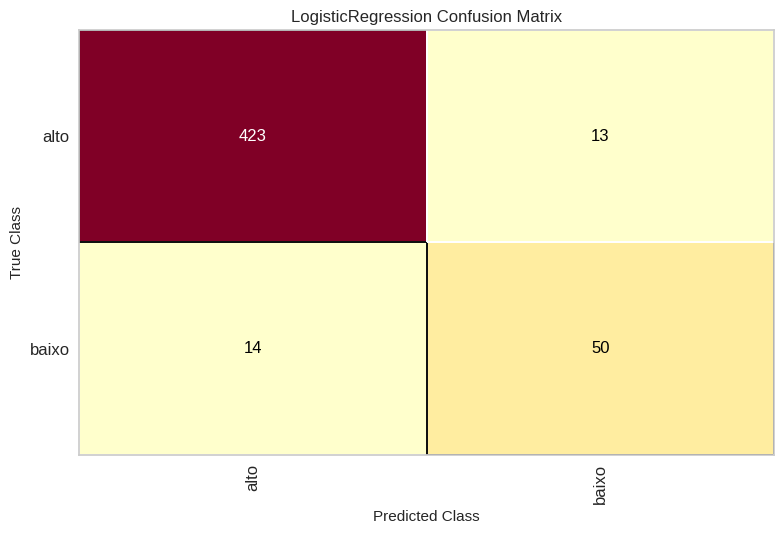

In [19]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(logistic_regression_credit, classes=TARGET_NAMES)
cm.fit(X_credit_train, y_credit_train)
cm.score(X_credit_test, y_credit_test)
cm.show()

plt.show()

In [20]:
from sklearn.metrics import classification_report

test_report = classification_report(
  y_credit_test,
  credit_predictions,
  target_names=TARGET_NAMES
)

print(f'Relatório com métricas: \n{test_report}')

Relatório com métricas: 
              precision    recall  f1-score   support

        alto       0.97      0.97      0.97       436
       baixo       0.79      0.78      0.79        64

    accuracy                           0.95       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.95      0.95      0.95       500



In [26]:
from sklearn.naive_bayes import GaussianNB

# Cálculo da acurácia de Naive Bayes
naive_credit = GaussianNB()
naive_credit.fit(X = X_credit_train, y = y_credit_train)

naive_predictions = naive_credit.predict(X_credit_test)
calculate_accuracy(y_credit_test, naive_predictions)

Previsões corretas:  469/500
Previsões incorretas: 31/500
Acurácia: 0.938


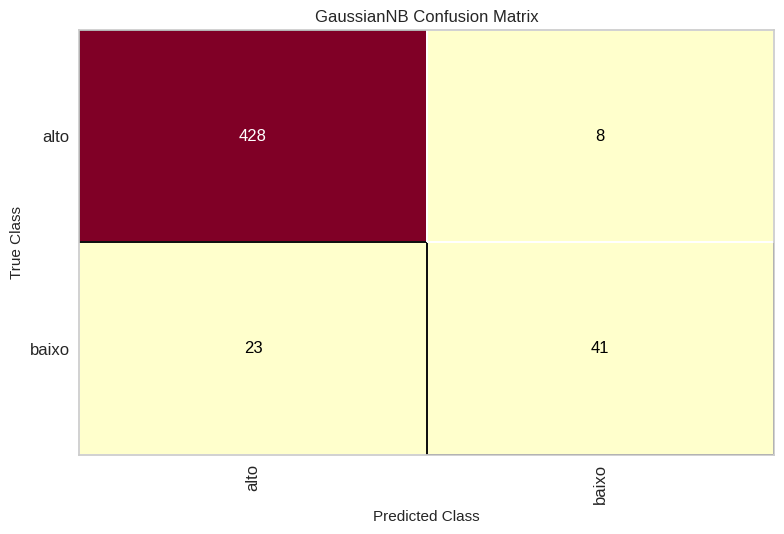

In [29]:
# Matriz de confusão de Naive Bayes
naive_cm = ConfusionMatrix(naive_credit, classes=TARGET_NAMES)
naive_cm.fit(X_credit_train, y_credit_train)
naive_cm.score(X_credit_test, y_credit_test)
naive_cm.show()

plt.show()

In [27]:
# Relatório de classificação do Naive Bayes
naive_report = classification_report(
  y_credit_test,
  naive_predictions,
  target_names=TARGET_NAMES
)

print(f'Relatório com métricas: \n{naive_report}')

Relatório com métricas: 
              precision    recall  f1-score   support

        alto       0.95      0.98      0.97       436
       baixo       0.84      0.64      0.73        64

    accuracy                           0.94       500
   macro avg       0.89      0.81      0.85       500
weighted avg       0.93      0.94      0.93       500

